# Real estate prices tracker

## EDA

### reading the dataset

In [1]:
import pandas as pd
import numpy as np


In [2]:
pwd()

'd:\\Projects\\real estate analysis\\scripts'

In [3]:
data = pd.read_csv(r"..\data\csv\magicbricks_mumbai_20260824_172759.csv")
data.head()

,OwnershipTypeD,ac,acD,achTdS,achTm,achTmS,actualOwner,adCn,ad_text,adroomD,...,tmsrt,transType,transactionTypeD,ty,ubicnt,url,userType,wapImgUrl,wapImgUrl1,waterStatus
0,NaN,11655.0,15 to 20 years,149,82,82,20435305,NaN,Sale Agent Mumbai Maharashtra India Sarwar A...,Store,...,84220,Sale,Resale,10002,50,2-BHK-800-Sq-ft-Multistorey-Apartment-FOR-Sale...,Agent,https://img.staticmb.com/mbphoto/property/crop...,https://img.staticmb.com/mbphoto/property/crop...,NaN
1,NaN,NaN,NaN,0,0,0,71157257,NaN,Sale Individual Mumbai Maharashtra India sha...,NaN,...,230931,Sale,Resale,10002,50,2-BHK-675-Sq-ft-Multistorey-Apartment-FOR-Sale...,Owner,https://img.staticmb.com/mbphoto/property/crop...,https://img.staticmb.com/mbphoto/property/crop...,NaN
2,NaN,NaN,NaN,0,0,0,46310463,NaN,Sale Individual Mumbai Maharashtra India Par...,NaN,...,122611,Sale,Resale,10001,50,2-BHK-300-Sq-ft-Residential-House-FOR-Sale-BMC...,Owner,https://img.staticmb.com/mbphoto/property/crop...,https://img.staticmb.com/mbphoto/property/crop...,NaN
3,NaN,NaN,NaN,0,0,0,46310269,NaN,Sale Individual Mumbai Maharashtra India Neh...,NaN,...,122329,Sale,Resale,10001,50,2-BHK-220-Sq-ft-Residential-House-FOR-Sale-Jar...,Owner,https://img.staticmb.com/mbphoto/property/crop...,https://img.staticmb.com/mbphoto/property/crop...,NaN
4,NaN,NaN,NaN,0,0,0,66560805,NaN,Sale Individual Mumbai Maharashtra India saq...,NaN,...,223128,Sale,Resale,10001,50,2-BHK-300-Sq-ft-Residential-House-FOR-Sale-Kaj...,Owner,https://img.staticmb.com/mbphoto/property/crop...,https://img.staticmb.com/mbphoto/property/crop...,NaN


In [4]:
# print(f"no. of rows, cols : {data.shape}\n")
print(f"info : {data.info()}\n")
# print(f"desc : {data.describe()}\n")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1196 entries, 0 to 1195
Columns: 278 entries, OwnershipTypeD to waterStatus
dtypes: bool(5), float64(67), int64(37), object(169)
memory usage: 2.5+ MB
info : None



In [5]:
# columns

colnames = data.columns
for i in colnames:
    print(i)

    

OwnershipTypeD
ac
acD
achTdS
achTm
achTmS
actualOwner
adCn
ad_text
adroomD
agComCt
agentContinuityStr
agentDetailUrl
agentReraState
agtCerStatus
agtCrSt
allImgCt
allImgPath
amenFacingD
amenities
ampDesc
appExc
appExcProp
appExcRe
appSub
appVer
appovedAuthC
attrImg
auto_desc
availUnit
availableFrom
avlAfter
b2cCardEligibility
balconiesD
bathD
bcp
bd
bedroomD
bookingAmtExact
brfdesc
brokerConnect
buyerCountbyPsm
cScore
ca
caCompNameD
caSqFt
carpAreaUnit
carpetArea
catAdd1
cg
cntvl
comFlag
comPantry
companyname
contName
covAreaUnit
covAreaUnitDesc
coverAreaUnitD
coveredArea
cowDays
cpmp
crisilNoOfEmployees
crisilOpSinceYear
crisilRv1CtBy
crisilStarRating
ct
ctCurr
ctLast
ctName
ctVerifd
ctaDetailBean
ctaRuleId
dImgRf
dImgSrc
dealDesc
defaultAdddressGoogle
devId
devName
deviceType
dimD
dsla
dtldesc
dues
ecd
encId
enc_Id
endDateT
endDt
exc
facingD
floorCsntrAllowed
floorD
floorNo
flooringTyD
floors
furnished
furnishedD
gateComm
grpBky1
grpBky2
grpBky3
grpBky4
grpBky5
grpBky6
grpBky7
iTarget

### selecting only needed cols

In [6]:
with open('colnames.txt','w') as file:
    for item in colnames:
        file.write(f"{item}\n")

In [7]:
with open("neededcols.txt", "r") as file:
    items = file.read().split(",")

In [8]:
items

['acD',
 'price',
 'priceD',
 'sqFtPrice',
 'minPrice',
 'maxPrice',
 'bedroomD',
 'bathD',
 'balconiesD',
 'carpetArea',
 'carpAreaUnit',
 'coveredArea',
 'covAreaUnit',
 'floorNo',
 'floors',
 'floorD',
 'furnishedD',
 'facingD',
 'amenFacingD',
 'propTypeD',
 'transactionTypeD',
 'possStatusD',
 'ecd',
 'rEcd',
 'landAreaUnit',
 'landAreaUnitD',
 'ct',
 'ctName',
 'loc',
 'locSeoName',
 'la',
 'pl',
 'prjname',
 'soc',
 'landmark',
 'landmarkDetails',
 'pmtLat',
 'pmtLong',
 'ltcoordGeo',
 'cg',
 'amenities',
 'luxAmenities',
 'luxAmenitiesD',
 'isLuxury',
 'isLuxuryServiceAvailable',
 'parkingD',
 'waterStatus',
 'powerStatusD',
 'maintenanceCharges',
 'maintenanceD',
 'flooringTyD',
 'reraValidity',
 'OwnershipTypeD',
 'postDateT',
 'modifiedDate',
 'lastAccessDate',
 'endDateT',
 'endDt',
 'cowDays',
 'dsla',
 'nriPref',
 'tenantsPreference',
 'propertyTitle',
 'adroomD',
 'caSqFt',
 'lmtDName']

In [9]:
cols_to_keep = items
existing_cols = [col for col in cols_to_keep if col in data.columns] 
data_needed_cols = data[existing_cols]

In [10]:
data_needed_cols.head(1)

,acD,price,priceD,sqFtPrice,minPrice,maxPrice,bedroomD,bathD,balconiesD,carpetArea,...,endDateT,endDt,cowDays,dsla,nriPref,tenantsPreference,propertyTitle,adroomD,caSqFt,lmtDName
0,15 to 20 years,200000.0,2 Lac,250.0,NaN,NaN,2,3,1,NaN,...,2026-10-21T18:30:00.000Z,"Oct 22, '26",0,NaN,NaN,Bachelors/Family,2BHK Multistorey Apartment for Resale in Bandr...,Store,800.0,Bandra West


In [11]:
data_needed_cols.to_csv(
    "data-with-neededcols.csv")

### Now we choose the columns we are gonna work with

In [12]:
imp_cols = ['acD','price','sqFtPrice','bedroomD','bathD','balconiesD','carpetArea','coveredArea','floorNo','floors','furnishedD','facingD','amenFacingD','propTypeD','transactionTypeD','possStatusD','ecd','ctName','locSeoName','prjname','landmark','lmtDName','ltcoordGeo','luxAmenitiesD','parkingD','waterStatus','powerStatusD','maintenanceCharges','maintenanceD','flooringTyD','reraValidity','OwnershipTypeD','tenantsPreference','postDateT','propertyTitle','adroomD']

In [13]:
working_dataset = data_needed_cols[imp_cols]
working_dataset.head(2)

,acD,price,sqFtPrice,bedroomD,bathD,balconiesD,carpetArea,coveredArea,floorNo,floors,...,powerStatusD,maintenanceCharges,maintenanceD,flooringTyD,reraValidity,OwnershipTypeD,tenantsPreference,postDateT,propertyTitle,adroomD
0,15 to 20 years,200000.0,250.0,2,3,1,NaN,800,6,10.0,...,NaN,NaN,NaN,Marble,NaN,NaN,Bachelors/Family,2026-08-23T14:55:10.000Z,2BHK Multistorey Apartment for Resale in Bandr...,Store
1,NaN,401303.0,595.0,2,2,NaN,NaN,675,12,22.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Bachelors/Family,2026-05-18T06:26:13.000Z,2BHK Multistorey Apartment for Resale in,NaN


In [14]:
print(working_dataset[['carpetArea','price']])

      carpetArea        price
0            NaN     200000.0
1            NaN     401303.0
2          300.0     940000.0
3          120.0     690000.0
4            NaN    1700000.0
...          ...          ...
1191      7100.0  960000000.0
1192      2120.0  120000000.0
1193      5499.0  600000000.0
1194      2146.0  120000000.0
1195      2200.0  600000000.0

[1196 rows x 2 columns]


### Data quality assessment

In [15]:
print(f"rows, cols: {working_dataset.shape}\n")

null_pct = (working_dataset.isnull().sum() / len(working_dataset) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
print("% missing per column:\n")
print(null_pct.round(1))

rows, cols: (1196, 36)

% missing per column:

maintenanceCharges    75.3
maintenanceD          71.4
adroomD               70.4
parkingD              70.2
powerStatusD          68.2
waterStatus           68.1
balconiesD            67.6
flooringTyD           65.6
landmark              65.6
amenFacingD           63.4
facingD               60.6
reraValidity          60.3
OwnershipTypeD        59.5
luxAmenitiesD         45.7
acD                   28.3
prjname               25.7
floors                16.8
floorNo               16.8
sqFtPrice             14.8
carpetArea            14.5
coveredArea           12.6
locSeoName             9.7
ltcoordGeo             5.2
lmtDName               5.2
price                  3.6
possStatusD            3.6
furnishedD             1.6
bathD                  0.9
transactionTypeD       0.1
dtype: float64


any column missing more than ~70% of its values isn't usable as a predictor, there just isn't enough signal. Dropping those now rather than trying to impute noise.

In [16]:
high_missing = null_pct[null_pct > 70].index.tolist()
print("Dropping (too sparse for 30 rows):", high_missing)

df = working_dataset.drop(columns=high_missing).copy()
df.shape

Dropping (too sparse for 30 rows): ['maintenanceCharges', 'maintenanceD', 'adroomD', 'parkingD']


(1196, 32)

### Cleaning individual fields

In [17]:
# floorNo mixes numbers with the string 'Ground' -> treat Ground as floor 0
df['floorNo'] = df['floorNo'].replace({'Ground': '0'})
df['floorNo'] = pd.to_numeric(df['floorNo'], errors='coerce')

# ecd is an int date like 20260813 -> proper datetime
df['ecd'] = pd.to_datetime(df['ecd'].astype(str), format='%Y%m%d', errors='coerce')

# postDateT is an ISO timestamp string -> datetime
df['postDateT'] = pd.to_datetime(df['postDateT'], errors='coerce')

# ltcoordGeo is "lat,long" packed into one string -> split into two numeric cols
coords = df['ltcoordGeo'].str.split(',', expand=True)
df['latitude'] = pd.to_numeric(coords[0], errors='coerce')
df['longitude'] = pd.to_numeric(coords[1], errors='coerce')
df = df.drop(columns=['ltcoordGeo'])

df[['floorNo', 'ecd', 'postDateT', 'latitude', 'longitude']].head()

,floorNo,ecd,postDateT,latitude,longitude
0,6.0,2026-08-24,2026-08-23 14:55:10+00:00,19.055229,72.830829
1,12.0,2026-05-18,2026-05-18 06:26:13+00:00,NaN,NaN
2,NaN,2026-08-24,2026-08-24 06:56:11+00:00,19.192963,72.822057
3,NaN,2026-08-24,2026-08-24 06:53:29+00:00,19.091147,72.882871
4,1.0,2026-05-27,2026-05-26 18:00:39+00:00,19.089349,72.886068


In [18]:
df['acD'].unique()

array(['15 to 20 years', nan, 'Less than 5 years', '10 to 15 years',
       'New Construction', 'Above 20 years', '5 to 10 years'],
      dtype=object)

In [19]:
# acD is a bucketed string like '10 to 15 years' -> map to a numeric midpoint
# so it can actually be used as a feature/plotted against price
age_map = {
    'New Construction': 0,
    '0 to 1 years': 0.5,
    'Less than 5 years' : 3,
    '1 to 5 years': 3,
    '5 to 10 years': 7.5,
    '10 to 15 years': 12.5,
    '15 to 20 years': 17.5,
    'Above 20 years': 25,
}
df['property_age_yrs'] = df['acD'].map(age_map)
df[['acD', 'property_age_yrs']].drop_duplicates()

,acD,property_age_yrs
0,15 to 20 years,17.5
1,NaN,NaN
7,Less than 5 years,3.0
12,10 to 15 years,12.5
15,New Construction,0.0
18,Above 20 years,25.0
25,5 to 10 years,7.5


In [20]:
print(df['bedroomD'].unique())
df['bedroomD'] = df['bedroomD'].replace({'> 10':10})
df['bedroomD'] = pd.to_numeric(df['bedroomD'], errors='coerce')
print(df['bedroomD'].unique())

['2' '3' '1' '4' '6' '9' '10' '8' '> 10' '7']
[ 2  3  1  4  6  9 10  8  7]


In [21]:
print(df['bathD'].unique())
df['bathD'] = df['bathD'].replace({'> 10':10})
df['bathD'] = pd.to_numeric(df['bathD'], errors='coerce')
print(df['bathD'].unique())

['3' '2' '1' nan '4' '5' '6' '7' '> 10' '10' '8' '9']
[ 3.  2.  1. nan  4.  5.  6.  7. 10.  8.  9.]


### Feature engineering

In [22]:
# recompute price per sqft from carpetArea and cross-check against the scraped sqFtPrice
df['price_per_sqft_calc'] = df['price'] / df['carpetArea']

check = df[['price', 'carpetArea', 'sqFtPrice', 'price_per_sqft_calc']].copy()
check['diff_pct'] = ((check['price_per_sqft_calc'] - check['sqFtPrice']) / check['sqFtPrice'] * 100).round(1)
check

,price,carpetArea,sqFtPrice,price_per_sqft_calc,diff_pct
0,200000.0,NaN,250.0,NaN,NaN
1,401303.0,NaN,595.0,NaN,NaN
2,940000.0,300.0,NaN,3133.333333,NaN
3,690000.0,120.0,3136.0,5750.000000,83.4
4,1700000.0,NaN,5667.0,NaN,NaN
...,...,...,...,...,...
1191,960000000.0,7100.0,480000.0,135211.267606,-71.8
1192,120000000.0,2120.0,47809.0,56603.773585,18.4
1193,600000000.0,5499.0,109091.0,109110.747409,0.0
1194,120000000.0,2146.0,47133.0,55917.986952,18.6


`sqFtPrice` looks like it's computed off `coveredArea` (built-up area) rather than `carpetArea`, that's the likely source of the gap above. Worth deciding which area definition to standardize on. I'll use `price_per_sqft_calc` (carpet-area based) going forward since carpet area is the more buyer-relevant number in the Indian market.

In [23]:
# days on market as of today, a liquidity signal
df['days_since_posted'] = (pd.Timestamp.now(tz=df['postDateT'].dt.tz) - df['postDateT']).dt.days

# ordinal encode furnishing since it has a natural order
furnish_order = {'Unfurnished': 0, 'Semi-Furnished': 1, 'Furnished': 2}
df['furnished_ord'] = df['furnishedD'].map(furnish_order)

df[['postDateT', 'days_since_posted', 'furnishedD', 'furnished_ord']].head()

,postDateT,days_since_posted,furnishedD,furnished_ord
0,2026-08-23 14:55:10+00:00,0,Furnished,2.0
1,2026-05-18 06:26:13+00:00,98,Semi-Furnished,1.0
2,2026-08-24 06:56:11+00:00,0,Unfurnished,0.0
3,2026-08-24 06:53:29+00:00,0,Unfurnished,0.0
4,2026-05-26 18:00:39+00:00,89,Unfurnished,0.0


### Exploratory analysis

In [24]:
df[['price', 'carpetArea', 'coveredArea', 'floorNo', 'floors',
    'property_age_yrs', 'price_per_sqft_calc', 'days_since_posted']].describe()

,price,carpetArea,floorNo,floors,property_age_yrs,price_per_sqft_calc,days_since_posted
count,1.153000e+03,1022.000000,992.000000,995.000000,857.000000,9.990000e+02,1196.000000
mean,1.258575e+12,1119.162427,10.515121,19.908543,8.575263,1.611760e+05,15.945652
std,4.273208e+13,833.498837,11.113749,16.831771,8.401602,1.874466e+06,30.632270
min,1.000000e+05,25.000000,0.000000,1.000000,0.000000,8.000000e+01,0.000000
25%,1.050000e+07,576.250000,3.000000,7.000000,3.000000,1.692653e+04,1.000000
50%,2.522000e+07,876.500000,7.000000,15.000000,7.500000,3.278689e+04,3.000000
75%,6.250000e+07,1400.750000,14.000000,23.000000,12.500000,5.203346e+04,6.250000
max,1.451005e+15,7560.000000,65.000000,91.000000,25.000000,3.822000e+07,135.000000


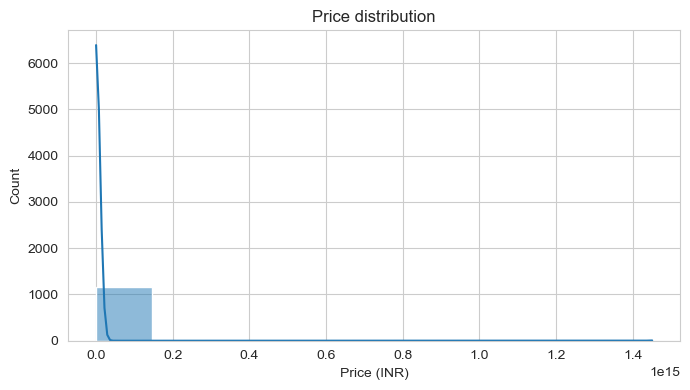

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df['price'], bins=10, kde=True, ax=ax)
ax.set_title('Price distribution')
ax.set_xlabel('Price (INR)')
plt.tight_layout()
plt.show()

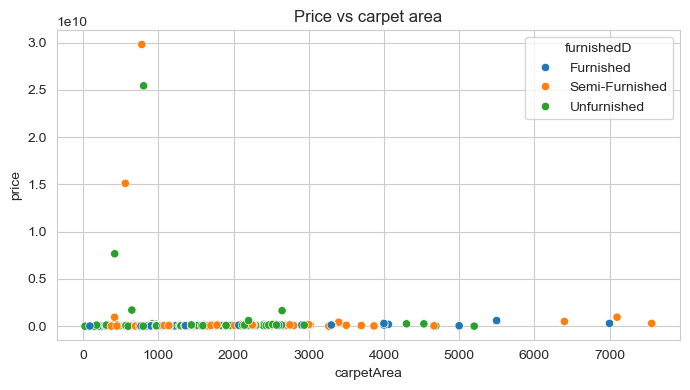

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(data=df, x='carpetArea', y='price', hue='furnishedD', ax=ax)
ax.set_title('Price vs carpet area')
plt.tight_layout()
plt.show()

                          mean  count
locSeoName                           
Goregaon East     8.061140e+13     18
Sewri West        1.274510e+10      2
Liberty Garden    7.670000e+09      1
Mahim West        2.199429e+09      7
Sector 2 Charkop  3.277333e+08      3
...                        ...    ...
JB Nagar                   NaN      0
Juhu Tara Road             NaN      0
Koliwada Manori            NaN      0
Miniland                   NaN      0
Sonapur                    NaN      0

[266 rows x 2 columns]


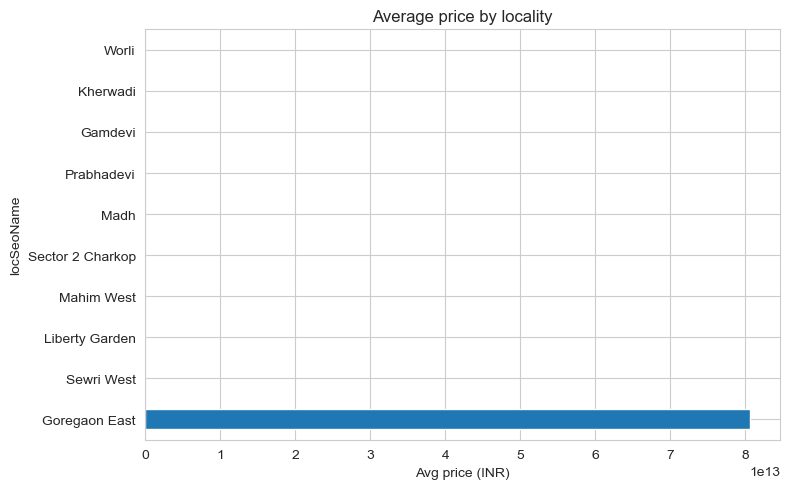

In [27]:
locality_price = (
    df.groupby('locSeoName')['price']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
)
print(locality_price)

fig, ax = plt.subplots(figsize=(8, 5))
locality_price['mean'].head(10).plot(kind='barh', ax=ax)
ax.set_title('Average price by locality')
ax.set_xlabel('Avg price (INR)')
plt.tight_layout()
plt.show()

In [28]:
df.columns

Index(['acD', 'price', 'sqFtPrice', 'bedroomD', 'bathD', 'balconiesD',
       'carpetArea', 'coveredArea', 'floorNo', 'floors', 'furnishedD',
       'facingD', 'amenFacingD', 'propTypeD', 'transactionTypeD',
       'possStatusD', 'ecd', 'ctName', 'locSeoName', 'prjname', 'landmark',
       'lmtDName', 'luxAmenitiesD', 'waterStatus', 'powerStatusD',
       'flooringTyD', 'reraValidity', 'OwnershipTypeD', 'tenantsPreference',
       'postDateT', 'propertyTitle', 'latitude', 'longitude',
       'property_age_yrs', 'price_per_sqft_calc', 'days_since_posted',
       'furnished_ord'],
      dtype='object')

In [50]:
df[df["coveredArea"].astype(str).str.contains(",",na=False)]

,acD,price,sqFtPrice,bedroomD,bathD,balconiesD,carpetArea,coveredArea,floorNo,floors,...,OwnershipTypeD,tenantsPreference,postDateT,propertyTitle,latitude,longitude,property_age_yrs,price_per_sqft_calc,days_since_posted,furnished_ord
856,NaN,950000000.0,61058.0,1,2.0,NaN,419.0,"15,559",22.0,22.0,...,Freehold,Bachelors/Family,2026-07-01 17:28:48+00:00,1BHK Multistorey Apartment for Resale in Jadei...,19.212220,72.821180,NaN,2.267303e+06,53,1.0
929,Less than 5 years,18500000.0,1682.0,4,4.0,2,3000.0,"11,000",NaN,NaN,...,Freehold,Bachelors/Family,2026-06-25 17:01:10+00:00,4BHK Villa for Resale in Virar East,19.465290,72.818999,3.0,6.166667e+03,59,1.0
1110,New Construction,50000000.0,0.0,10,10.0,> 10,5000.0,"10,000",NaN,NaN,...,NaN,Bachelors/Family,2026-05-21 16:53:56+00:00,> 10BHK Villa for Resale in Mumbai Central,18.971936,72.820090,0.0,1.000000e+04,94,2.0
1169,15 to 20 years,300000000.0,28571.0,6,6.0,NaN,7560.0,"10,500",3.0,40.0,...,NaN,Bachelors/Family,2026-08-20 12:09:24+00:00,6BHK Multistorey Apartment for Resale in Belve...,18.986562,72.818287,17.5,3.968254e+04,4,1.0


In [51]:
df["coveredArea"] = pd.to_numeric(df["coveredArea"].astype(str).str.replace(",",""),errors='coerce')

In [52]:
numeric_cols = ['price', 'bedroomD','bathD','carpetArea', 'coveredArea', 'floorNo', 'floors',
                 'property_age_yrs', 'furnished_ord', 'days_since_posted']
for cols in numeric_cols:
    print(f"{cols}: {df[cols].dtype}")

price: float64
bedroomD: int64
bathD: float64
carpetArea: float64
coveredArea: float64
floorNo: float64
floors: float64
property_age_yrs: float64
furnished_ord: float64
days_since_posted: int64


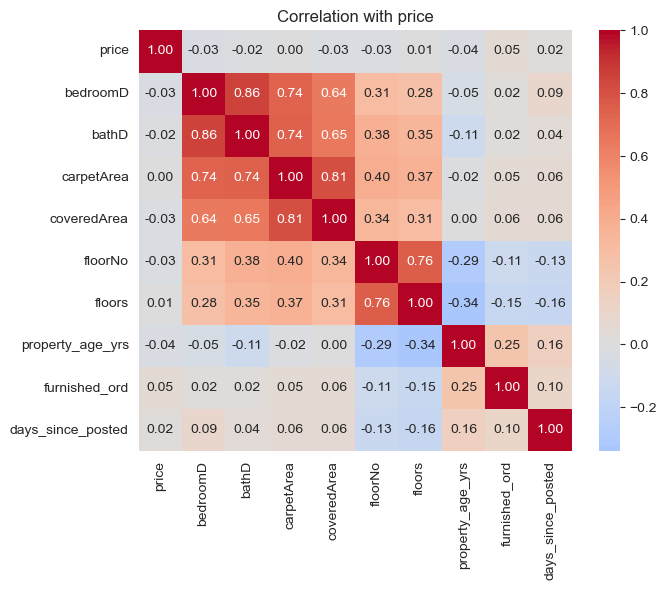

In [53]:
numeric_cols = ['price', 'bedroomD','bathD','carpetArea', 'coveredArea', 'floorNo', 'floors',
                 'property_age_yrs', 'furnished_ord', 'days_since_posted']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation with price')
plt.tight_layout()
plt.show()

In [95]:
# checking for outliers
num_df =  df["price"]

Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3-Q1

#True if any feature in the row is an outlier
is_outlier_row = ((num_df < (Q1-1.5*IQR)) |(num_df > (Q3+1.5*IQR)))

outlier_rows = df[is_outlier_row]
print(outlier_rows.shape)

(41, 37)


In [100]:
from scipy import stats
import numpy as np

# Calculate Z-scores per column
z_scores = np.abs(stats.zscore(num_df, nan_policy='omit'))

# Filter rows where at least one column has |Z| > 3
outlier_rows2 = df[(z_scores > 3)]
print(outlier_rows2.shape)
outlier_rows2

(1, 37)


,acD,price,sqFtPrice,bedroomD,bathD,balconiesD,carpetArea,coveredArea,floorNo,floors,...,OwnershipTypeD,tenantsPreference,postDateT,propertyTitle,latitude,longitude,property_age_yrs,price_per_sqft_calc,days_since_posted,furnished_ord
852,New Construction,1.451005e+15,3.463018e+12,1,2.0,NaN,NaN,419.0,1.0,23.0,...,Freehold,Bachelors/Family,2026-07-24 18:08:40+00:00,1BHK Multistorey Apartment for Resale in Build...,19.156211,72.875809,0.0,NaN,30,2.0


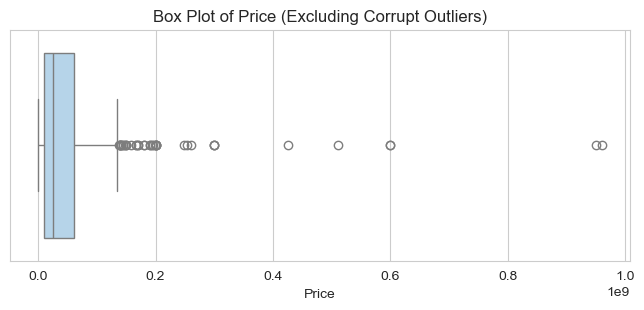

In [104]:
# Filter out values > 1 billion to see the actual distribution
filtered_df = df[df['price'] < 1e9]

plt.figure(figsize=(8, 3))
sns.boxplot(x=filtered_df['price'], color='#aed6f1')
plt.title('Box Plot of Price (Excluding Corrupt Outliers)')
plt.xlabel('Price')
plt.show()

In [105]:
df['price'].describe(percentiles=[0.50, 0.90, 0.95, 0.99])

count    1.153000e+03
mean     1.258575e+12
std      4.273208e+13
min      1.000000e+05
50%      2.522000e+07
90%      1.007496e+08
95%      1.300000e+08
99%      4.658000e+08
max      1.451005e+15
Name: price, dtype: float64

In [106]:
# Keep only rows where price is under 1 Billion
df_clean = df[df['price'] < 1e9].copy()

# Verify the new summary stats
df_clean['price'].describe()

count    1.146000e+03
mean     4.435351e+07
std      6.426835e+07
min      1.000000e+05
25%      1.050000e+07
50%      2.500000e+07
75%      6.075000e+07
max      9.600000e+08
Name: price, dtype: float64

### Reality check before modeling

A few things stand out that need addressing before Phase 4 (modeling):

- **Columns like `parkingD`, `waterStatus`, `powerStatusD`, `maintenanceCharges`, `reraValidity` were dropped** for >70% missingness, they may come back once the scrape is larger and less sparse.



### Save cleaned dataset

In [124]:
df.to_csv("cleaned_dataset.csv", index=False)
print(f"Saved cleaned_dataset.csv -> {df.shape[0]} rows, {df.shape[1]} cols")

Saved cleaned_dataset.csv -> 518 rows, 29 cols
